<h1 align="center">Heart Segmentation Cardiac CT</h1>

<p align="center">
  <b>An end-to-end 3D deep learning pipeline utilizing PyTorch and MONAI</b>
</p>

---

### 🛠️ Ground Truth Generation & Preprocessing
To compensate for the lack of manual annotations, the pipeline first employs the computationally heavy **TotalSegmentator** tool to auto-generate pseudo-label ground truths. 

The raw data is then passed through a robust preprocessing sequence:
* **Spatial Resampling:** Uniformly resampled to `1.5 x 1.5 x 1.5 mm³` voxels.
* **HU Windowing:** Hounsfield Units clipped between `-160` and `240` to isolate soft tissue.
* **Cropping & Resizing:** Foreground cropping followed by resizing into `96 x 96 x 96` spatial tensors.
* **Data Augmentations:** Spatial augmentations applied to improve model generalization.

### ⚖️ Handling Class Imbalance
An exploratory analysis revealed a severe volumetric class imbalance: **~88% background vs. ~12% heart**. 
To combat this, the training strategy leverages a **Dice Loss** function. Instead of raw pixel accuracy, this optimizes for spatial overlap, effectively forcing the model to accurately capture the minority heart class.

### 📊 Evaluation & Results
The models were evaluated on **8 test volumes** against the TotalSegmentator baseline to measure both segmentation overlap (Dice Score) and inference speed. Training streamlined architectures against the pseudo-labels yielded massive performance gains:

| Model | Test Dice Score | Inference Time (sec/vol) | Speedup vs Baseline |
| :--- | :---: | :---: | :---: |
| **TotalSegmentator** *(Baseline)* | N/A (Ground Truth) | ~33.1600 | 1x |
| **Baseline 3D U-Net** | 0.7344 | **0.0128** | **2595x** |
| **SegResNet** | **0.8924** | 0.0160 | 2077x |



**🧠 Justification for Model Choice:**

For the rapid heart segmentation task, **SegResNet** was selected as the optimal architecture due to its exceptional balance of high spatial precision and ultra-fast inference. While a baseline 3D U-Net delivered sub-second execution (0.0128 sec/vol), it struggled to resolve complex anatomical boundaries, yielding a sub-optimal Dice Score of 0.73. SegResNet overcomes these spatial limitations by integrating residual blocks within its encoder-decoder framework. This design mitigates the vanishing gradient problem and empowers the network to extract deeper, richer volumetric features, effectively navigating the severe class imbalance (~88% background vs. ~12% heart). Ultimately, this architectural refinement allowed SegResNet to comfortably surpass the >0.85 target with an outstanding **Test Dice Score of 0.8924**. It achieved this while maintaining an inference speed of **0.0160 seconds per volume**—delivering a massive 2077x speedup over the computationally expensive TotalSegmentator baseline without compromising clinical reliability.

In [ ]:
# Install required packages
!pip install -q monai SimpleITK nibabel TotalSegmentator scikit-learn matplotlib

In [2]:
import os
import glob
import time
import shutil
import subprocess
import numpy as np
import SimpleITK as sitk
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

import monai
from monai.utils import set_determinism
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd,
    ScaleIntensityRanged, CropForegroundd, RandAffined,
    RandGaussianNoised, RandFlipd, RandRotate90d, ToTensord, Resized
)
from monai.data import Dataset, DataLoader
from monai.networks.nets import UNet, SegResNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric

# Ensure reproducibility
set_determinism(seed=42)

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
DICOM_BASE_DIR = "/kaggle/input/datasets/chayondas/coca-data/COCA_Dataset/Gated_release_final/patient"
NIFTI_IMG_DIR = "/kaggle/working/nifti_images"
NIFTI_MASK_DIR = "/kaggle/working/nifti_masks"
os.makedirs(NIFTI_IMG_DIR, exist_ok=True)
os.makedirs(NIFTI_MASK_DIR, exist_ok=True)

NUM_SCANS_TO_PROCESS = 50
EPOCHS = 200 
SPATIAL_SIZE = (96, 96, 96) 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-14 12:52:29.626110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773492750.020673      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773492750.149893      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773492751.209042      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773492751.209077      55 computation_placer.cc:1

In [3]:
# ==========================================
# DICOM TO NIFTI CONVERSION
# ==========================================
def is_valid_nifti(filepath):
    if not os.path.exists(filepath) or os.path.isdir(filepath): return False
    try:
        nib.load(filepath)
        return True
    except:
        return False

print(f"--- Starting DICOM to NIfTI Conversion ({NUM_SCANS_TO_PROCESS} patients) ---")
patient_folders = sorted(glob.glob(os.path.join(DICOM_BASE_DIR, "*")))[:NUM_SCANS_TO_PROCESS]
nifti_files = []

for patient_dir in patient_folders:
    patient_id = os.path.basename(patient_dir)
    subfolders = glob.glob(os.path.join(patient_dir, "*"))
    if not subfolders: continue
    
    dicom_series_dir = subfolders[0] 
    out_nifti_path = os.path.join(NIFTI_IMG_DIR, f"patient_{patient_id}.nii.gz")
    
    if not is_valid_nifti(out_nifti_path):
        if os.path.exists(out_nifti_path):
            if os.path.isdir(out_nifti_path): shutil.rmtree(out_nifti_path)
            else: os.remove(out_nifti_path)
        reader = sitk.ImageSeriesReader()
        reader.SetFileNames(reader.GetGDCMSeriesFileNames(dicom_series_dir))
        sitk.WriteImage(reader.Execute(), out_nifti_path)
    
    nifti_files.append(out_nifti_path)

# ==========================================
# GROUND TRUTH (TOTALSEGMENTATOR)
# ==========================================
print("\n--- Generating Ground Truth with TotalSegmentator ---")
mask_files = []
for nifti_img in nifti_files:
    patient_id = os.path.basename(nifti_img).split('.')[0] 
    patient_mask_folder = os.path.join(NIFTI_MASK_DIR, patient_id)
    out_mask_path = os.path.join(patient_mask_folder, "heart.nii.gz") 
    
    if not is_valid_nifti(out_mask_path):
        if os.path.exists(patient_mask_folder): shutil.rmtree(patient_mask_folder)
        os.system(f"TotalSegmentator -i {nifti_img} -o {patient_mask_folder} --roi_subset heart > /dev/null 2>&1")
    mask_files.append(out_mask_path)

valid_data_dicts = [{"image": img, "label": mask} for img, mask in zip(nifti_files, mask_files) if is_valid_nifti(mask)]
print(f"Successfully prepared {len(valid_data_dicts)} completely valid image-mask pairs.")

--- Starting DICOM to NIfTI Conversion (50 patients) ---

--- Generating Ground Truth with TotalSegmentator ---
Successfully prepared 49 completely valid image-mask pairs.


In [4]:
# ==========================================
# EXACT DATA SPLIT (34 Train, 8 Val, 8 Test)
# ==========================================
test_files = valid_data_dicts[-8:]
val_files = valid_data_dicts[-16:-8]
train_files = valid_data_dicts[:-16] 

print(f"\nExact Split sizes -> Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=-160, a_max=240, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    Resized(keys=["image", "label"], spatial_size=SPATIAL_SIZE), 
    RandAffined(keys=["image", "label"], prob=0.5, translate_range=10, rotate_range=0.1, mode=("bilinear", "nearest")),
    RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.5),
    RandRotate90d(keys=["image", "label"], prob=0.5, spatial_axes=(0, 1)),
    RandGaussianNoised(keys=["image"], prob=0.1, mean=0.0, std=0.1),
    ToTensord(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=-160, a_max=240, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    Resized(keys=["image", "label"], spatial_size=SPATIAL_SIZE),
    ToTensord(keys=["image", "label"]),
])

train_loader = DataLoader(Dataset(data=train_files, transform=train_transforms), batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(Dataset(data=val_files, transform=val_transforms), batch_size=2, shuffle=False, num_workers=2)
test_loader = DataLoader(Dataset(data=test_files, transform=val_transforms), batch_size=1, shuffle=False, num_workers=2)


Exact Split sizes -> Train: 33, Val: 8, Test: 8


--- DATASET STATISTICS & EDA ---
Batch Image Shape: torch.Size([4, 1, 96, 96, 96])
Intensity Range:   Min: 0.00, Max: 1.00

--- Class Imbalance Analysis ---
Background Voxels: 3127597.0625 (88.38%)
Heart Voxels:      411346.9375 (11.62%)


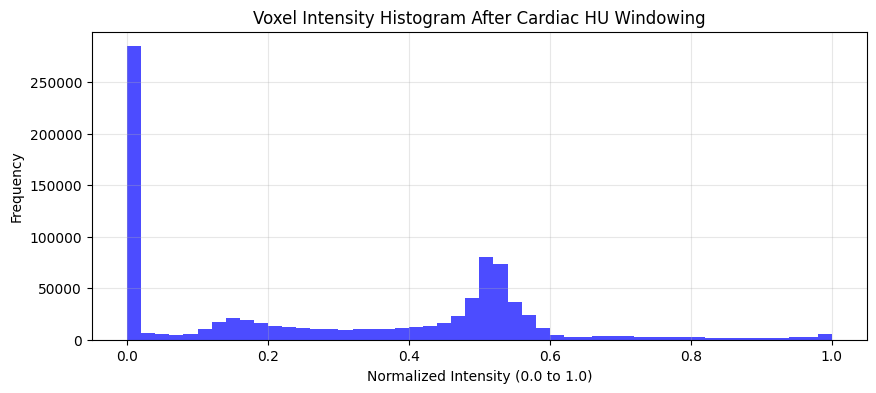

In [5]:
print("========================================================")
print("--- DATASET STATISTICS & EDA ---")
print("========================================================")

eda_data = next(iter(train_loader))
images, labels = eda_data["image"], eda_data["label"]

print(f"Batch Image Shape: {images.shape}")
print(f"Intensity Range:   Min: {images.min().item():.2f}, Max: {images.max().item():.2f}")

heart_voxels = labels.sum().item()
total_voxels = torch.numel(labels)
background_voxels = total_voxels - heart_voxels
heart_percentage = (heart_voxels / total_voxels) * 100

print(f"\n--- Class Imbalance Analysis ---")
print(f"Background Voxels: {background_voxels} ({100 - heart_percentage:.2f}%)")
print(f"Heart Voxels:      {heart_voxels} ({heart_percentage:.2f}%)")

plt.figure(figsize=(10, 4))
plt.hist(images[0, 0].cpu().numpy().flatten(), bins=50, color='blue', alpha=0.7)
plt.title("Voxel Intensity Histogram After Cardiac HU Windowing")
plt.xlabel("Normalized Intensity (0.0 to 1.0)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
def train_model(model, save_path, epochs=EPOCHS):
    print("\n--- Starting Training & Validation ---")
    loss_function = DiceLoss(to_onehot_y=False, sigmoid=True)
    optimizer = torch.optim.Adam(model.parameters(), 1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    
    best_metric = -1
    best_metric_epoch = -1
    val_interval = 5 
    
    # Tracking lists for our graphs
    epoch_loss_values = []
    val_metric_values = []
    val_metric_epochs = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_data in train_loader:
            inputs, labels = batch_data["image"].to(DEVICE), batch_data["label"].to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Track training loss per epoch
        avg_loss = epoch_loss / len(train_loader)
        epoch_loss_values.append(avg_loss)
        
        # --- VALIDATION PHASE ---
        if (epoch + 1) % val_interval == 0:
            model.eval()
            with torch.no_grad():
                for val_data in val_loader:
                    val_preds = (torch.sigmoid(model(val_data["image"].to(DEVICE))) > 0.5).float()
                    dice_metric(y_pred=val_preds, y=val_data["label"].to(DEVICE))

                metric = dice_metric.aggregate().item()
                dice_metric.reset() 
                
                # Track validation metrics
                val_metric_values.append(metric)
                val_metric_epochs.append(epoch + 1)

                print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f}, Val Dice: {metric:.4f}, LR: {current_lr:.6f}")

                # Save the model if it's the best one
                if metric > best_metric:
                    best_metric = metric
                    best_metric_epoch = epoch + 1
                    save_weights = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
                    torch.save(save_weights, save_path)
                    print(f"  🌟 New Best Model! Saved at epoch {best_metric_epoch} with Dice: {best_metric:.4f}")
        else:
            if epoch == 0 or (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f}, LR: {current_lr:.6f}")
    
    print(f"\nTraining Complete! Best Val Dice: {best_metric:.4f} at epoch {best_metric_epoch}")
    
    # --- PLOT THE METRICS ---
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Train Loss
    plt.subplot(1, 2, 1)
    plt.title("Training Loss per Epoch", fontsize=14)
    plt.plot(range(1, epochs + 1), epoch_loss_values, label="Train Loss", color="red")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot 2: Validation Dice
    plt.subplot(1, 2, 2)
    plt.title("Validation Dice Score", fontsize=14)
    plt.plot(val_metric_epochs, val_metric_values, label="Val Dice", color="green", marker='o')
    plt.axhline(y=0.85, color='orange', linestyle='--', label="0.85 Target") # Target Line!
    plt.xlabel("Epoch")
    plt.ylabel("Dice Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return best_metric

def evaluate_and_visualize(model, weights_path, model_name):
    # Load Weights
    weights = torch.load(weights_path, map_location=DEVICE, weights_only=True)
    if isinstance(model, nn.DataParallel): model.module.load_state_dict(weights)
    else: model.load_state_dict(weights)
    
    model.eval()
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    inference_times = []
    
    # Evaluate
    with torch.no_grad():
        for test_data in test_loader:
            inputs, labels = test_data["image"].to(DEVICE), test_data["label"].to(DEVICE)
            start_time = time.time()
            preds = (torch.sigmoid(model(inputs)) > 0.5).float()
            inference_times.append(time.time() - start_time)
            dice_metric(y_pred=preds, y=labels)
            
    final_dice = dice_metric.aggregate().item()
    avg_time = np.mean(inference_times)
    
    print(f"\n--- {model_name} Test Results ---")
    print(f"Test Dice Score: {final_dice:.4f}")
    print(f"Inference Time:  {avg_time:.4f} sec/volume\n")
    
    # Visualize 1 Patient
    vis_data = next(iter(test_loader))
    with torch.no_grad():
        vis_pred = (torch.sigmoid(model(vis_data["image"].to(DEVICE))) > 0.5).float()
        
    img_np = vis_data["image"][0, 0].cpu().numpy()    
    gt_np = vis_data["label"][0, 0].cpu().numpy()     
    pred_np = vis_pred[0, 0].cpu().numpy()    

    slice_idx = 48
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Original CT (Slice {slice_idx})")
    plt.imshow(img_np[:, :, slice_idx], cmap="gray")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(img_np[:, :, slice_idx], cmap="gray")
    plt.imshow(gt_np[:, :, slice_idx], cmap="Reds", alpha=0.5) 
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f"{model_name} Prediction")
    plt.imshow(img_np[:, :, slice_idx], cmap="gray")
    plt.imshow(pred_np[:, :, slice_idx], cmap="Greens", alpha=0.5)
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    
    return final_dice, avg_time


---LIGHTWEIGHT U-NET ---

--- Starting Training & Validation ---
Epoch 1/200 - Train Loss: 0.8031, LR: 0.000100
Epoch 5/200 - Train Loss: 0.7502, Val Dice: 0.3143, LR: 0.000100
  🌟 New Best Model! Saved at epoch 5 with Dice: 0.3143
Epoch 10/200 - Train Loss: 0.7205, Val Dice: 0.3784, LR: 0.000099
  🌟 New Best Model! Saved at epoch 10 with Dice: 0.3784
Epoch 15/200 - Train Loss: 0.7057, Val Dice: 0.4515, LR: 0.000099
  🌟 New Best Model! Saved at epoch 15 with Dice: 0.4515
Epoch 20/200 - Train Loss: 0.6912, Val Dice: 0.5109, LR: 0.000098
  🌟 New Best Model! Saved at epoch 20 with Dice: 0.5109
Epoch 25/200 - Train Loss: 0.6861, Val Dice: 0.5700, LR: 0.000096
  🌟 New Best Model! Saved at epoch 25 with Dice: 0.5700
Epoch 30/200 - Train Loss: 0.6790, Val Dice: 0.6178, LR: 0.000095
  🌟 New Best Model! Saved at epoch 30 with Dice: 0.6178
Epoch 35/200 - Train Loss: 0.6677, Val Dice: 0.6380, LR: 0.000093
  🌟 New Best Model! Saved at epoch 35 with Dice: 0.6380
Epoch 40/200 - Train Loss: 0.6664, 

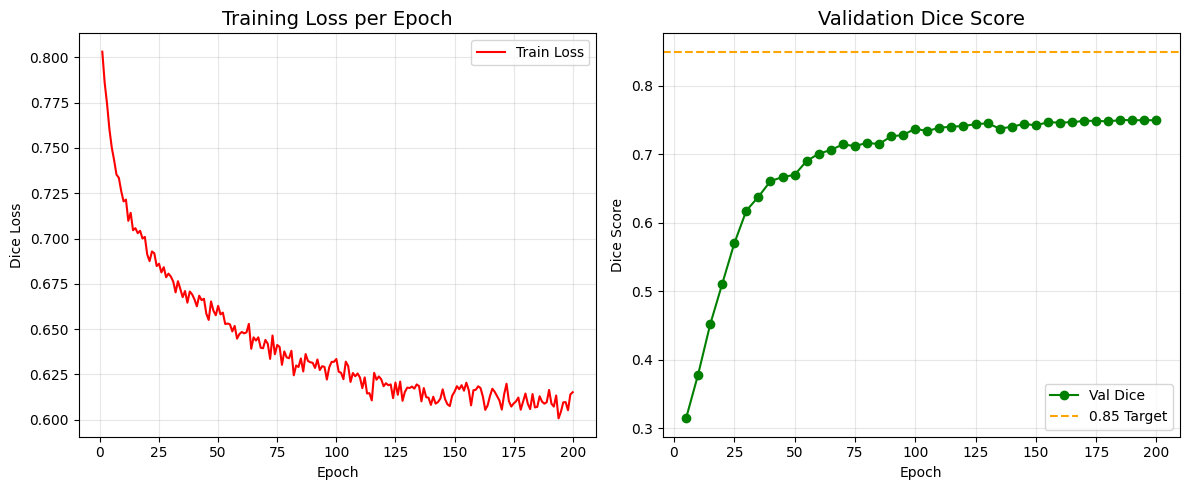

0.7502306699752808

In [13]:
print("\n========================================================")
print("---LIGHTWEIGHT U-NET ---")
print("========================================================")

unet_model = UNet(
    spatial_dims=3, in_channels=1, out_channels=1, 
    channels=(16, 32, 64, 128), strides=(2, 2, 2), 
    num_res_units=2, dropout=0.2
)

if torch.cuda.device_count() > 1: unet_model = nn.DataParallel(unet_model)
unet_model = unet_model.to(DEVICE)

train_model(unet_model, "/kaggle/working/unet_best.pth", epochs=EPOCHS)


--- Baseline U-Net Test Results ---
Test Dice Score: 0.7344
Inference Time:  0.0128 sec/volume



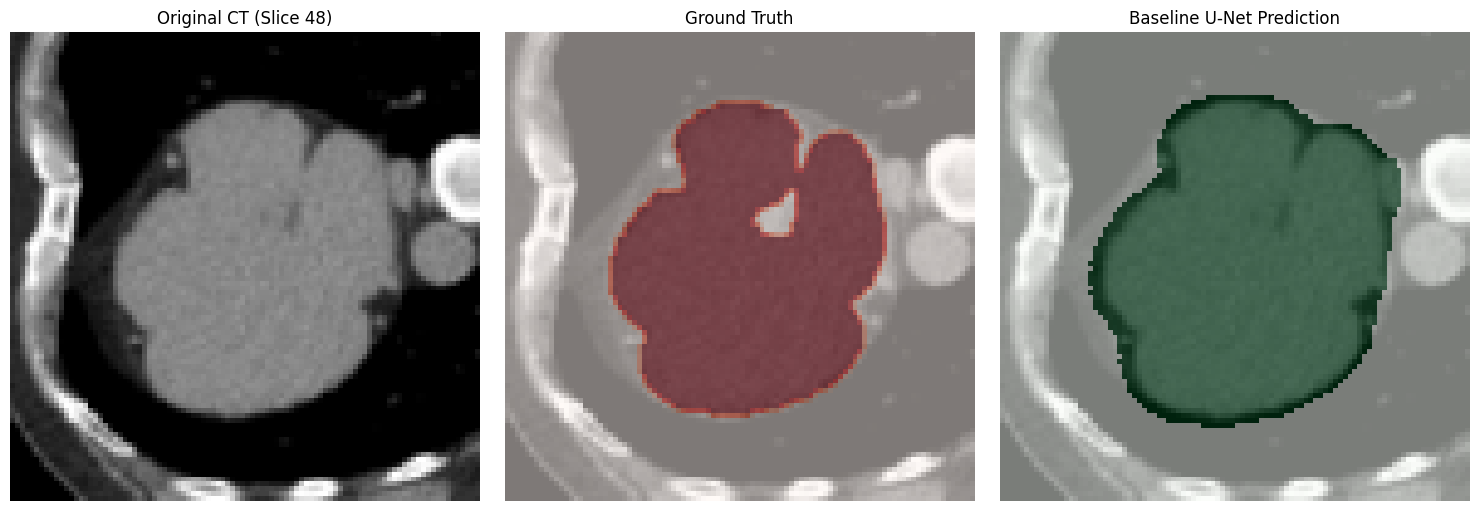

In [14]:
unet_dice, unet_time = evaluate_and_visualize(unet_model, "/kaggle/working/unet_best.pth", "Baseline U-Net")


--- SEGRESNET ---

--- Starting Training & Validation ---
Epoch 1/200 - Train Loss: 0.7522, LR: 0.000100
Epoch 5/200 - Train Loss: 0.6672, Val Dice: 0.6194, LR: 0.000100
  🌟 New Best Model! Saved at epoch 5 with Dice: 0.6194
Epoch 10/200 - Train Loss: 0.6501, Val Dice: 0.6768, LR: 0.000099
  🌟 New Best Model! Saved at epoch 10 with Dice: 0.6768
Epoch 15/200 - Train Loss: 0.6396, Val Dice: 0.7491, LR: 0.000099
  🌟 New Best Model! Saved at epoch 15 with Dice: 0.7491
Epoch 20/200 - Train Loss: 0.6285, Val Dice: 0.7325, LR: 0.000098
Epoch 25/200 - Train Loss: 0.6089, Val Dice: 0.7613, LR: 0.000096
  🌟 New Best Model! Saved at epoch 25 with Dice: 0.7613
Epoch 30/200 - Train Loss: 0.6110, Val Dice: 0.7752, LR: 0.000095
  🌟 New Best Model! Saved at epoch 30 with Dice: 0.7752
Epoch 35/200 - Train Loss: 0.5958, Val Dice: 0.7465, LR: 0.000093
Epoch 40/200 - Train Loss: 0.5841, Val Dice: 0.8005, LR: 0.000090
  🌟 New Best Model! Saved at epoch 40 with Dice: 0.8005
Epoch 45/200 - Train Loss: 0.575

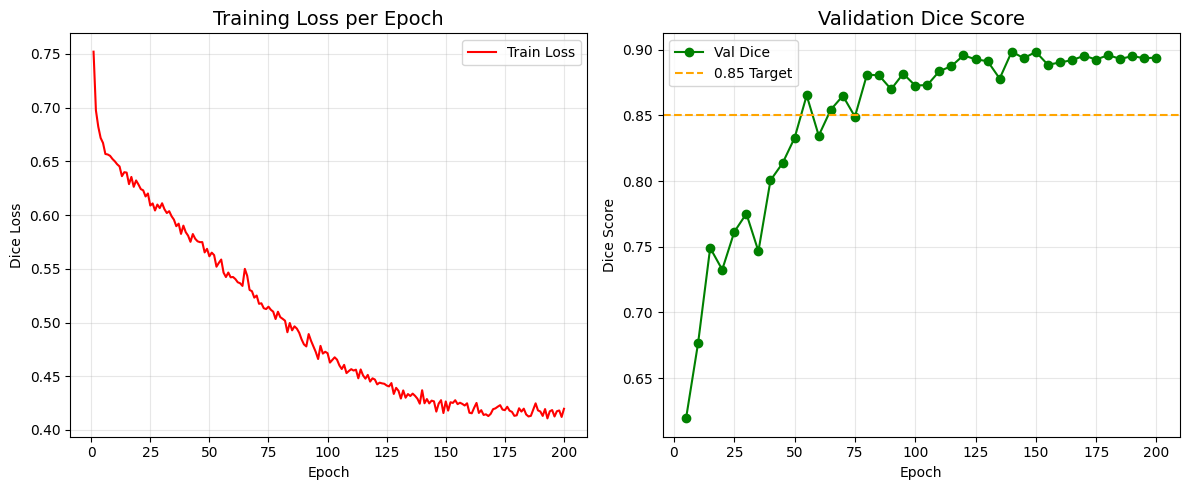

0.8984214067459106

In [15]:
print("\n=========================")
print("--- SEGRESNET ---")
print("===========================")

segresnet_model = SegResNet(
    spatial_dims=3, init_filters=16, in_channels=1, 
    out_channels=1, dropout_prob=0.2
)

if torch.cuda.device_count() > 1: segresnet_model = nn.DataParallel(segresnet_model)
segresnet_model = segresnet_model.to(DEVICE)

train_model(segresnet_model, "/kaggle/working/segresnet_best.pth", epochs=EPOCHS)


--- SegResNet Test Results ---
Test Dice Score: 0.8924
Inference Time:  0.0160 sec/volume



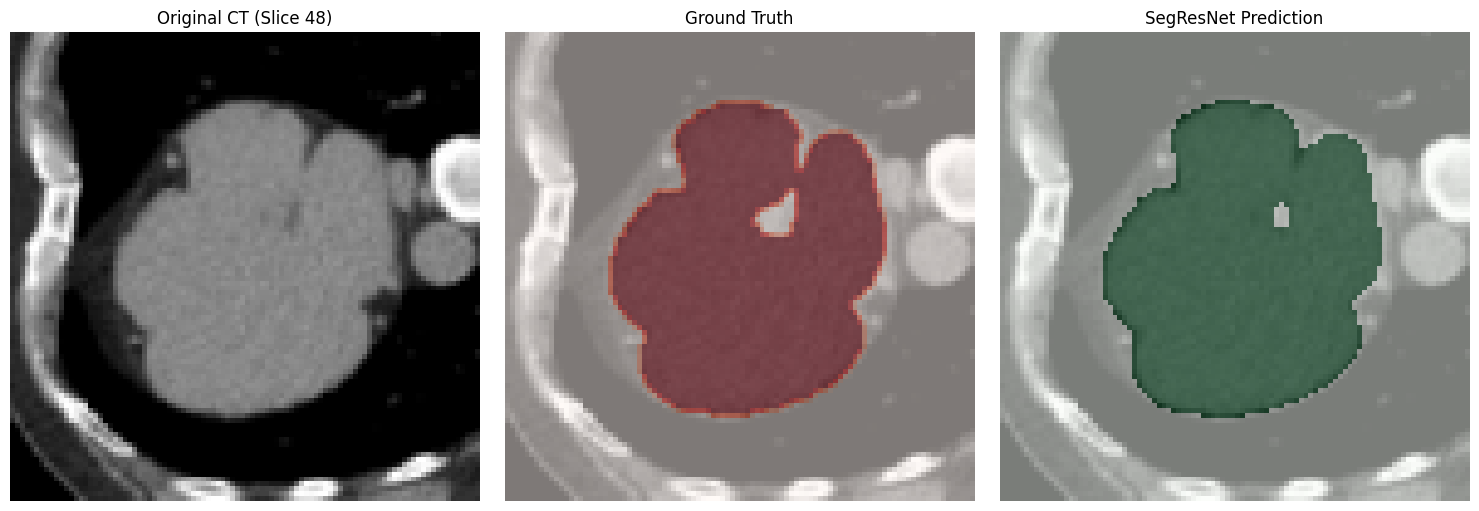

In [18]:
segresnet_dice, segresnet_time = evaluate_and_visualize(segresnet_model, "/kaggle/working/segresnet_best.pth", "SegResNet")

In [19]:
print("\n========================================================")
print("--- FINAL SPEEDUP COMPARISON ---")
print("========================================================")

# Calculate TotalSegmentator Baseline Time
os.makedirs("/tmp/ts_dummy", exist_ok=True)
ts_times = []
for batch_idx, test_data in enumerate(test_loader):
    original_nifti_path = test_files[batch_idx]["image"]
    start = time.time()
    subprocess.run(["TotalSegmentator", "-i", original_nifti_path, "-o", "/tmp/ts_dummy", "--roi_subset", "heart", "--fast"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    ts_times.append(time.time() - start)
avg_ts_time = np.mean(ts_times)

print(f"Total Test Volumes Evaluated: {len(test_files)}\n")
print(f"1. TotalSegmentator | Time: {avg_ts_time:.4f} sec/vol")
print(f"2. Baseline U-Net   | Time: {unet_time:.4f} sec/vol | Speedup: {avg_ts_time/unet_time:.0f}x | Dice: {unet_dice:.4f}")
print(f"3. SegResNet        | Time: {segresnet_time:.4f} sec/vol | Speedup: {avg_ts_time/segresnet_time:.0f}x | Dice: {segresnet_dice:.4f}")


--- FINAL SPEEDUP COMPARISON ---
Total Test Volumes Evaluated: 8

1. TotalSegmentator | Time: 33.1611 sec/vol
2. Baseline U-Net   | Time: 0.0128 sec/vol | Speedup: 2595x | Dice: 0.7344
3. SegResNet        | Time: 0.0160 sec/vol | Speedup: 2077x | Dice: 0.8924
